### 1. n-step Sarsa

n-step Sarsa is a **model-free, on-policy** reinforcement learning method that extends one-step Sarsa by using multiple future rewards before performing an update.

Instead of updating after every single step, the algorithm waits for \(n\) time steps (or until the episode terminates) and then updates the action-value function using a combination of observed rewards and a bootstrapped estimate.

The n-step return is defined as:

$$
G_\tau^{(n)} =
\sum_{i=\tau+1}^{\min(\tau+n, T)} \gamma^{\,i-\tau-1} R_i
+
\gamma^n Q(S_{\tau+n}, A_{\tau+n}) \quad \text{if } \tau+n < T.
$$

The update rule is:

$$
Q(S_\tau, A_\tau)
\leftarrow
Q(S_\tau, A_\tau)
+
\alpha
\Big[
G_\tau^{(n)} - Q(S_\tau, A_\tau)
\Big].
$$

n-step Sarsa is **on-policy**, meaning that it evaluates and improves the same policy that is used to generate behavior (typically an $\varepsilon$-greedy policy). The update depends on the actual actions taken $A_{\tau+1}, \dots, A_{\tau+n}$, rather than assuming greedy actions.

Because of this, n-step Sarsa naturally accounts for the effects of exploration during learning.

In practice:
- Small \(n\) (e.g., 1) gives low variance but higher bias  
- Large \(n\) approaches Monte Carlo methods with higher variance but lower bias  

Thus, \(n\) controls the trade-off between bias and variance.

In environments like Cliff Walking, n-step Sarsa often learns safer policies than Q-learning because it takes into account the exploratory behavior of the $\varepsilon$-greedy policy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import GridWorld as GW

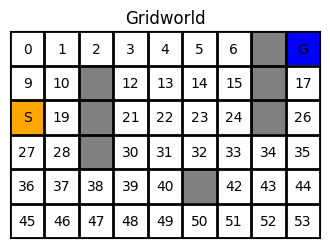

In [3]:
gw = GW.Sutton_Barto_Example8_1()
gw.plot_gridworld()

In [4]:
from GridWorld import GridWorld

def epsilon_greedy_policy(gridworld, Q, epsilon=0.1):

    policy = np.zeros_like(Q)
    states_, actions_ = np.nonzero((Q.T == np.max(Q, axis=1)).T)
    n_actions = len(gridworld.actions)
    for s in np.arange(gridworld.nstates):
        greedy_action = np.random.choice(actions_[states_ == s])
        for a in range(len(gridworld.actions)):
            if a != greedy_action:
                policy[s, a] = epsilon / n_actions
            else:
                policy[s, a] = 1.0 - epsilon + epsilon / n_actions

    return policy

def n_step_bootstrapping(gridworld: GridWorld,
                         n: int,
                         episodes=10, 
                         gamma=0.95, 
                         alpha=0.1):
    
    n_actions = len(gridworld.actions)
    Q = np.zeros((gridworld.nstates, n_actions))

    for _ in range(episodes):

        # Episode buffers
        states = []
        actions = []
        rewards = [0]

        # initial state and action
        S = gridworld.initial_state
        states.append(S)

        policy = epsilon_greedy_policy(gridworld, Q)

        a_idx = np.random.choice(n_actions, p=policy[S])
        actions.append(a_idx)

        T = float('inf')
        t = 0

        while True:
            
            if t < T:
                S = states[t]
                A = gridworld.actions[actions[t]]

                S_, R = gridworld.interact(S, A)

                states.append(S_)
                rewards.append(R)

                if S_ == gridworld.terminal_state:
                    T = t + 1
                else:
                    a_idx = np.random.choice(n_actions, p=policy[S_])
                    actions.append(a_idx)
            
            tau = t - n + 1

            if tau >= 0:

                G = 0.0
                upper = min(tau+n, T)
                for i in range(tau+1, upper+1):
                    G += (gamma ** (i-tau-1)) * rewards[i]
                
                # Bootstrap if not terminal
                if tau + n < T:
                    s_boot = states[tau + n]
                    a_boot = actions[tau + n]
                    G += (gamma ** n) * Q[s_boot, a_boot]

                s_tau = states[tau]
                a_tau = actions[tau]

                Q[s_tau, a_tau] += alpha * (G - Q[s_tau, a_tau])

            if tau == T - 1:
                break

            t += 1

    return Q, epsilon_greedy_policy(gridworld, Q, epsilon=0.0)


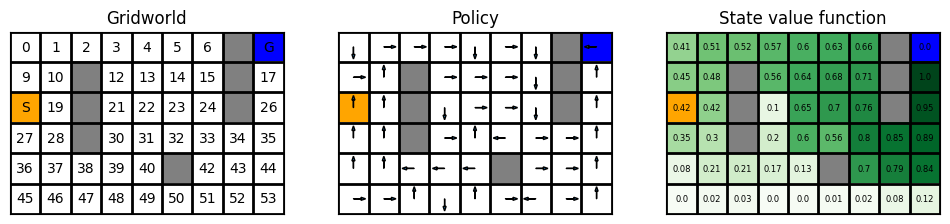

In [7]:
Q, policy = n_step_bootstrapping(gw, n=5, episodes=1000)
V = np.sum(policy * Q, axis=1)

gw.plot_overview(V, policy)